# Backpropagation and Gradient Descent

## Part 1 – Gradient Descent Fundamentals (From Scratch)

### 1.1 Simple Linear Regression

We implement gradient descent manually to learn the parameters of a simple linear model: $y = wx + b$

The true relationship is: $y = 3x + 2 + \text{noise}$

In [2]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(7460)

In [3]:
# Task 1: Generate 100 data points
# True parameters: w=3, b=2
n_samples = 100
X = np.random.uniform(-10, 10, n_samples)
noise = np.random.normal(0, 1, n_samples)
y_true = 3 * X + 2 + noise

print(f"Generated {n_samples} data points")
print(f"X shape: {X.shape}, y shape: {y_true.shape}")

Generated 100 data points
X shape: (100,), y shape: (100,)


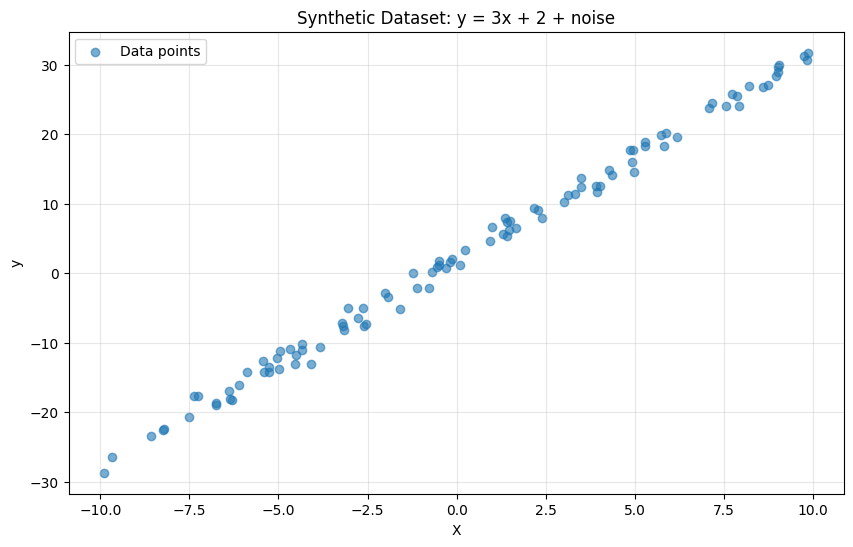

In [4]:
# Visualize the data
plt.figure(figsize=(10, 6))
plt.scatter(X, y_true, alpha=0.6, label='Data points')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Synthetic Dataset: y = 3x + 2 + noise')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [5]:
# Task 2: Initialize parameters w and b randomly
w = np.random.randn()
b = np.random.randn()

print(f"Initial parameters: w = {w:.4f}, b = {b:.4f}")
print(f"True parameters: w = 3, b = 2")

Initial parameters: w = -0.1846, b = 0.0711
True parameters: w = 3, b = 2


In [6]:
def compute_predictions(X, w, b):
    """Task 3: Compute predictions"""
    return w * X + b

def compute_mse_loss(y_true, y_pred):
    """Task 3: Compute Mean Squared Error loss"""
    return np.mean((y_true - y_pred) ** 2)

def compute_gradients(X, y_true, y_pred):
    """Task 4: Compute gradients manually
    
    Gradient w.r.t. w: -2 * mean(x * (y - y_pred))
    Gradient w.r.t. b: -2 * mean(y - y_pred)
    """
    n = len(y_true)
    dw = -2 * np.mean(X * (y_true - y_pred))
    db = -2 * np.mean(y_true - y_pred)
    return dw, db

def gradient_descent(X, y_true, w_init, b_init, learning_rate, n_iterations):
    """Task 5: Update parameters using gradient descent"""
    w = w_init
    b = b_init
    loss_history = []
    
    for i in range(n_iterations):
        # Forward pass: compute predictions
        y_pred = compute_predictions(X, w, b)
        
        # Compute loss
        loss = compute_mse_loss(y_true, y_pred)
        loss_history.append(loss)
        
        # Compute gradients
        dw, db = compute_gradients(X, y_true, y_pred)
        
        # Update parameters
        w = w - learning_rate * dw
        b = b - learning_rate * db
        
        if i % 100 == 0:
            print(f"Iteration {i}: Loss = {loss:.4f}, w = {w:.4f}, b = {b:.4f}")
    
    return w, b, loss_history

In [7]:
# Train the model
learning_rate = 0.01
n_iterations = 1000

# Re-initialize parameters
np.random.seed(42)
w_init = np.random.randn()
b_init = np.random.randn()

w_final, b_final, loss_history = gradient_descent(
    X, y_true, w_init, b_init, learning_rate, n_iterations
)

print(f"\nFinal parameters: w = {w_final:.4f}, b = {b_final:.4f}")
print(f"True parameters: w = 3, b = 2")

Iteration 0: Loss = 186.9866, w = 1.9448, b = -0.0788
Iteration 100: Loss = 1.1988, w = 2.9796, b = 1.7177
Iteration 200: Loss = 1.1216, w = 2.9767, b = 1.9562
Iteration 300: Loss = 1.1202, w = 2.9764, b = 1.9881
Iteration 400: Loss = 1.1202, w = 2.9763, b = 1.9924
Iteration 500: Loss = 1.1202, w = 2.9763, b = 1.9929
Iteration 600: Loss = 1.1202, w = 2.9763, b = 1.9930
Iteration 700: Loss = 1.1202, w = 2.9763, b = 1.9930
Iteration 800: Loss = 1.1202, w = 2.9763, b = 1.9930
Iteration 900: Loss = 1.1202, w = 2.9763, b = 1.9930

Final parameters: w = 2.9763, b = 1.9930
True parameters: w = 3, b = 2


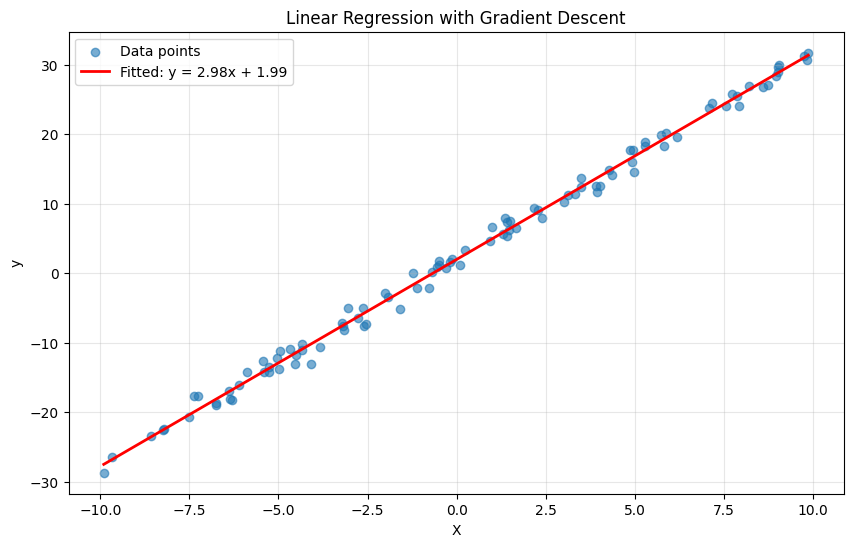

In [8]:
# Visualize the fitted line
plt.figure(figsize=(10, 6))
plt.scatter(X, y_true, alpha=0.6, label='Data points')
X_line = np.linspace(X.min(), X.max(), 100)
y_line = w_final * X_line + b_final
plt.plot(X_line, y_line, 'r-', linewidth=2, label=f'Fitted: y = {w_final:.2f}x + {b_final:.2f}')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Linear Regression with Gradient Descent')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 1.2 Loss Curve Visualization

Track the loss value for each iteration and plot loss vs iterations.

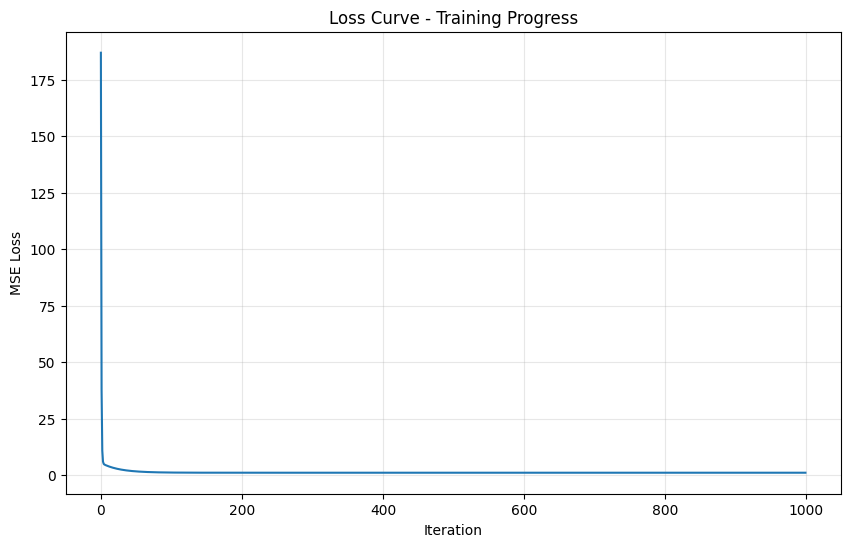

Initial Loss: 186.9866
Final Loss: 1.1202


In [9]:
# Plot loss vs iterations
plt.figure(figsize=(10, 6))
plt.plot(loss_history)
plt.xlabel('Iteration')
plt.ylabel('MSE Loss')
plt.title('Loss Curve - Training Progress')
plt.grid(True, alpha=0.3)
plt.show()

print(f"Initial Loss: {loss_history[0]:.4f}")
print(f"Final Loss: {loss_history[-1]:.4f}")

### 1.3 Effect of Learning Rate

Train the model using three different learning rates and compare their convergence behavior.

Iteration 0: Loss = 186.9866, w = 0.6415, b = -0.1323
Iteration 100: Loss = 4.0718, w = 2.9911, b = 0.2753
Iteration 200: Loss = 3.1004, w = 2.9934, b = 0.5858
Iteration 300: Loss = 2.4492, w = 2.9903, b = 0.8402
Iteration 400: Loss = 2.0122, w = 2.9878, b = 1.0486
Iteration 500: Loss = 1.7189, w = 2.9857, b = 1.2193
Iteration 600: Loss = 1.5220, w = 2.9840, b = 1.3592
Iteration 700: Loss = 1.3899, w = 2.9826, b = 1.4737
Iteration 800: Loss = 1.3012, w = 2.9815, b = 1.5676
Iteration 900: Loss = 1.2417, w = 2.9805, b = 1.6445
Iteration 0: Loss = 186.9866, w = 1.9448, b = -0.0788
Iteration 100: Loss = 1.1988, w = 2.9796, b = 1.7177
Iteration 200: Loss = 1.1216, w = 2.9767, b = 1.9562
Iteration 300: Loss = 1.1202, w = 2.9764, b = 1.9881
Iteration 400: Loss = 1.1202, w = 2.9763, b = 1.9924
Iteration 500: Loss = 1.1202, w = 2.9763, b = 1.9929
Iteration 600: Loss = 1.1202, w = 2.9763, b = 1.9930
Iteration 700: Loss = 1.1202, w = 2.9763, b = 1.9930
Iteration 800: Loss = 1.1202, w = 2.9763, b 

/home/abzy/dev/aitu/masters/trimester2/aitu-masters-advanced-ml/endterm/.venv/lib/python3.13/site-packages/numpy/_core/_methods.py:132: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/tmp/ipykernel_777788/238847835.py:7: RuntimeWarning: overflow encountered in square
  return np.mean((y_true - y_pred) ** 2)
/home/abzy/dev/aitu/masters/trimester2/aitu-masters-advanced-ml/endterm/.venv/lib/python3.13/site-packages/numpy/_core/_methods.py:132: RuntimeWarning: invalid value encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/tmp/ipykernel_777788/238847835.py:38: RuntimeWarning: invalid value encountered in scalar subtract
  w = w - learning_rate * dw
/home/abzy/dev/aitu/masters/trimester2/aitu-masters-advanced-ml/endterm/.venv/lib/python3.13/site-packages/matplotlib/scale.py:270: RuntimeWarning: overflow encountered in power
  return np.power(self.base, values)


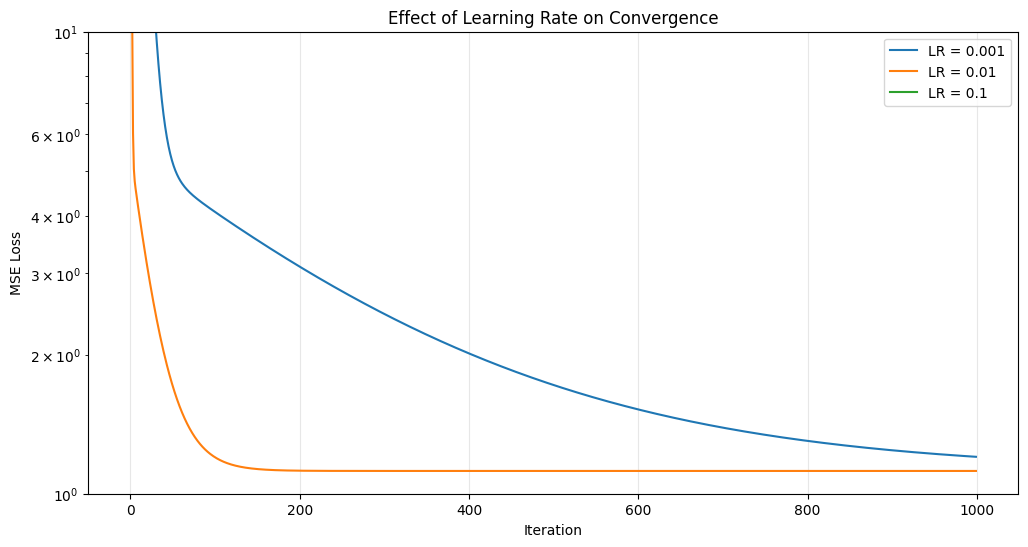

In [10]:
# Compare different learning rates
learning_rates = [0.001, 0.01, 0.1]
n_iterations = 1000

plt.figure(figsize=(12, 6))

for lr in learning_rates:
    np.random.seed(42)
    w_init = np.random.randn()
    b_init = np.random.randn()
    
    _, _, loss_hist = gradient_descent(X, y_true, w_init, b_init, lr, n_iterations)
    plt.plot(loss_hist, label=f'LR = {lr}')

plt.xlabel('Iteration')
plt.ylabel('MSE Loss')
plt.title('Effect of Learning Rate on Convergence')
plt.legend()
plt.grid(True, alpha=0.3)
plt.yscale('log')  # Log scale to better visualize differences
plt.show()

Iteration 0: Loss = 186.9866, w = 0.6415, b = -0.1323
Iteration 0: Loss = 186.9866, w = 1.9448, b = -0.0788
Iteration 0: Loss = 186.9866, w = 14.9774, b = 0.4563


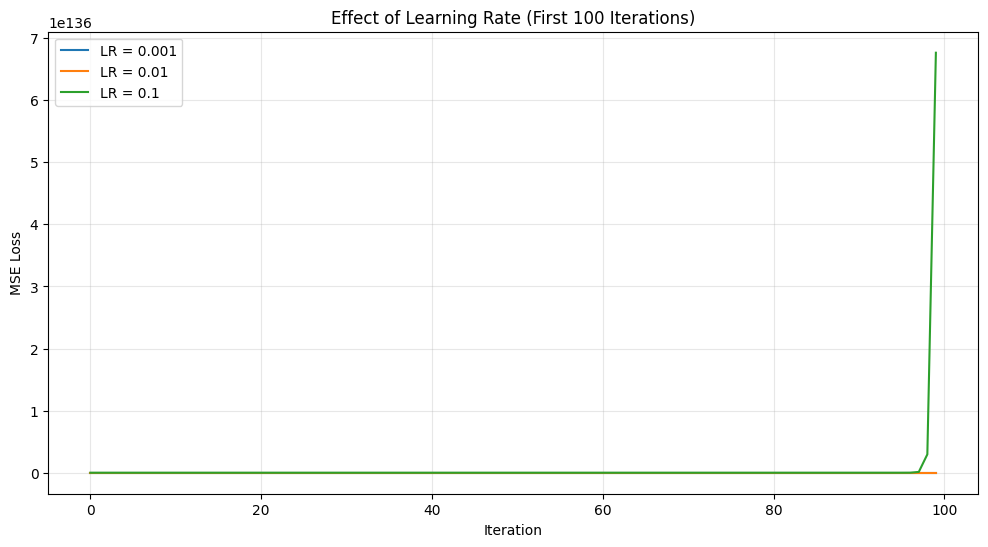

In [11]:
# Zoomed view for first 100 iterations
plt.figure(figsize=(12, 6))

for lr in learning_rates:
    np.random.seed(42)
    w_init = np.random.randn()
    b_init = np.random.randn()
    
    _, _, loss_hist = gradient_descent(X, y_true, w_init, b_init, lr, 100)
    plt.plot(loss_hist, label=f'LR = {lr}')

plt.xlabel('Iteration')
plt.ylabel('MSE Loss')
plt.title('Effect of Learning Rate (First 100 Iterations)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**Observations:**
- **LR = 0.001 (too small):** Slow convergence, loss decreases gradually
- **LR = 0.01 (good):** Balanced convergence speed
- **LR = 0.1 (larger):** Fast convergence, but can become unstable with larger values

## Part 2 – Visualizing Gradient Descent

### 2.1 Loss Surface Visualization

Create a contour plot of the loss surface to visualize how the loss changes with different values of w and b.

In [12]:
# Create a grid of values for w and b
w_range = np.linspace(-2, 8, 100)
b_range = np.linspace(-4, 8, 100)
W, B = np.meshgrid(w_range, b_range)

# Compute the loss for each pair (w, b)
Loss_surface = np.zeros(W.shape)

for i in range(W.shape[0]):
    for j in range(W.shape[1]):
        y_pred = W[i, j] * X + B[i, j]
        Loss_surface[i, j] = compute_mse_loss(y_true, y_pred)

print(f"Loss surface shape: {Loss_surface.shape}")
print(f"Min loss: {Loss_surface.min():.4f}")

Loss surface shape: (100, 100)
Min loss: 1.1443


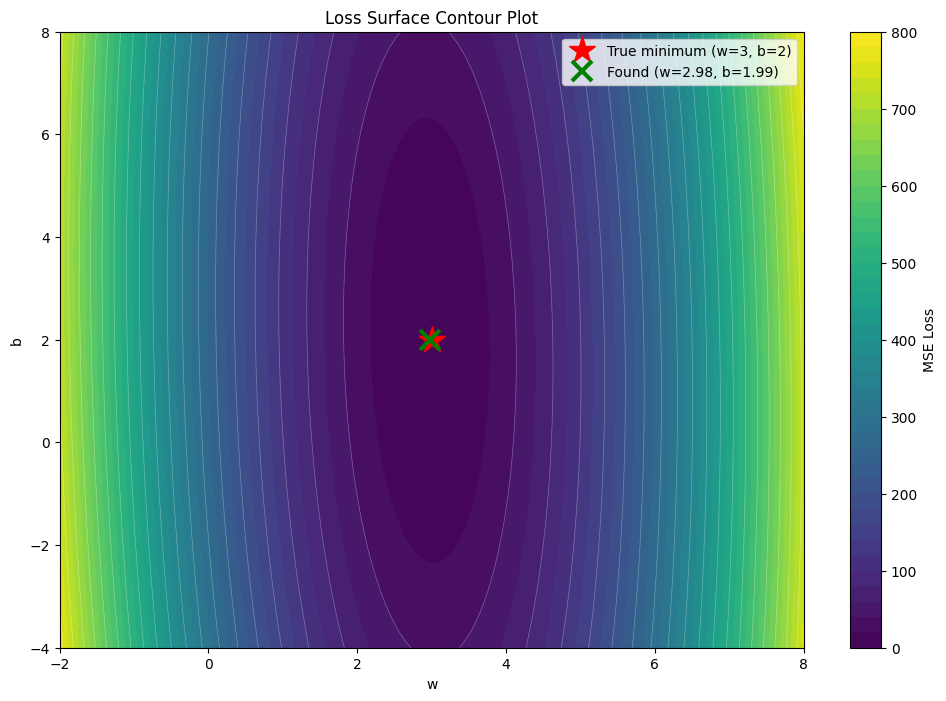

In [13]:
# Plot contour of the loss surface
plt.figure(figsize=(12, 8))

# Filled contour plot
contour = plt.contourf(W, B, Loss_surface, levels=50, cmap='viridis')
plt.colorbar(contour, label='MSE Loss')

# Add contour lines
plt.contour(W, B, Loss_surface, levels=20, colors='white', alpha=0.3, linewidths=0.5)

# Mark the true minimum (w=3, b=2)
plt.plot(3, 2, 'r*', markersize=20, label='True minimum (w=3, b=2)')

# Mark the found minimum
plt.plot(w_final, b_final, 'gx', markersize=15, markeredgewidth=3, label=f'Found (w={w_final:.2f}, b={b_final:.2f})')

plt.xlabel('w')
plt.ylabel('b')
plt.title('Loss Surface Contour Plot')
plt.legend()
plt.show()

In [14]:
# Track the path of gradient descent on the loss surface
def gradient_descent_with_path(X, y_true, w_init, b_init, learning_rate, n_iterations):
    """Gradient descent that also tracks the path of (w, b) values"""
    w = w_init
    b = b_init
    path_w = [w]
    path_b = [b]
    
    for i in range(n_iterations):
        y_pred = compute_predictions(X, w, b)
        dw, db = compute_gradients(X, y_true, y_pred)
        w = w - learning_rate * dw
        b = b - learning_rate * db
        path_w.append(w)
        path_b.append(b)
    
    return np.array(path_w), np.array(path_b)

# Get the path
np.random.seed(42)
w_init = np.random.randn()
b_init = np.random.randn()
path_w, path_b = gradient_descent_with_path(X, y_true, w_init, b_init, 0.01, 500)

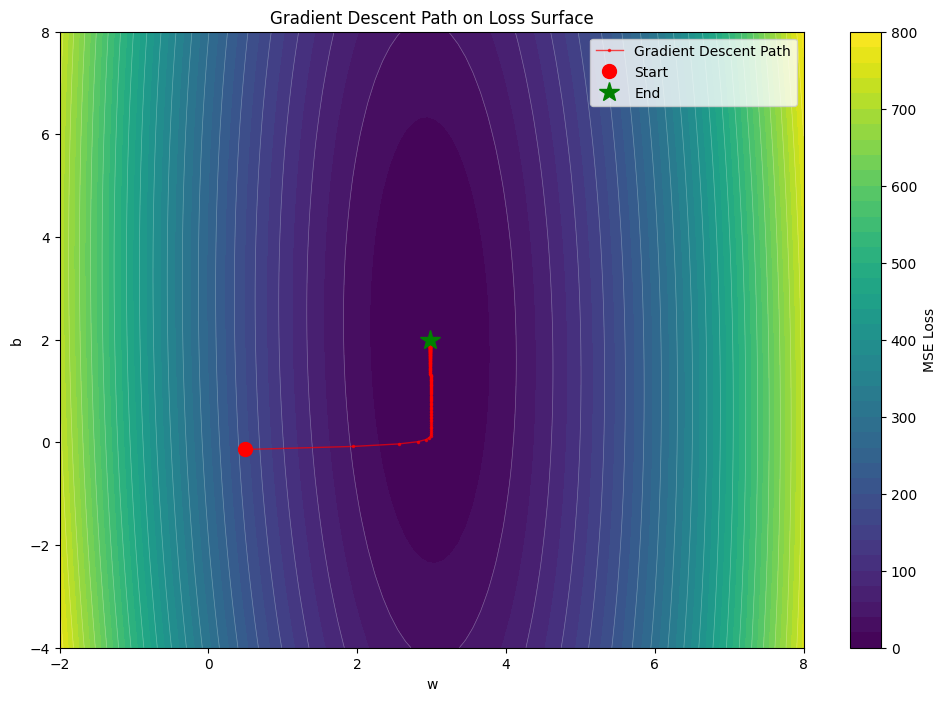

In [15]:
# Plot the gradient descent path on the loss surface
plt.figure(figsize=(12, 8))

contour = plt.contourf(W, B, Loss_surface, levels=50, cmap='viridis')
plt.colorbar(contour, label='MSE Loss')
plt.contour(W, B, Loss_surface, levels=20, colors='white', alpha=0.3, linewidths=0.5)

# Plot the path
plt.plot(path_w, path_b, 'r.-', markersize=3, linewidth=1, alpha=0.7, label='Gradient Descent Path')
plt.plot(path_w[0], path_b[0], 'ro', markersize=10, label='Start')
plt.plot(path_w[-1], path_b[-1], 'g*', markersize=15, label='End')

plt.xlabel('w')
plt.ylabel('b')
plt.title('Gradient Descent Path on Loss Surface')
plt.legend()
plt.show()

## Part 3 – Backpropagation with a Neural Network

### 3.1 Dataset Preparation

Load the MNIST dataset, normalize pixel values to [0, 1], and flatten input images.

In [16]:
import tensorflow as tf
from tensorflow import keras

print(f"TensorFlow version: {tf.__version__}")

2026-02-05 17:10:27.134283: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-02-05 17:10:27.134769: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-05 17:10:27.169690: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-05 17:10:30.969841: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off,

TensorFlow version: 2.20.0


In [17]:
# Load MNIST dataset
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")
print(f"Training labels shape: {y_train.shape}")
print(f"Number of classes: {len(np.unique(y_train))}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Training set shape: (60000, 28, 28)
Test set shape: (10000, 28, 28)
Training labels shape: (60000,)
Number of classes: 10


In [18]:
# Normalize pixel values to [0, 1]
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

print(f"Pixel value range: [{X_train.min()}, {X_train.max()}]")

Pixel value range: [0.0, 1.0]


In [19]:
# Flatten input images (28x28 -> 784)
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

print(f"Flattened training set shape: {X_train_flat.shape}")
print(f"Flattened test set shape: {X_test_flat.shape}")

Flattened training set shape: (60000, 784)
Flattened test set shape: (10000, 784)


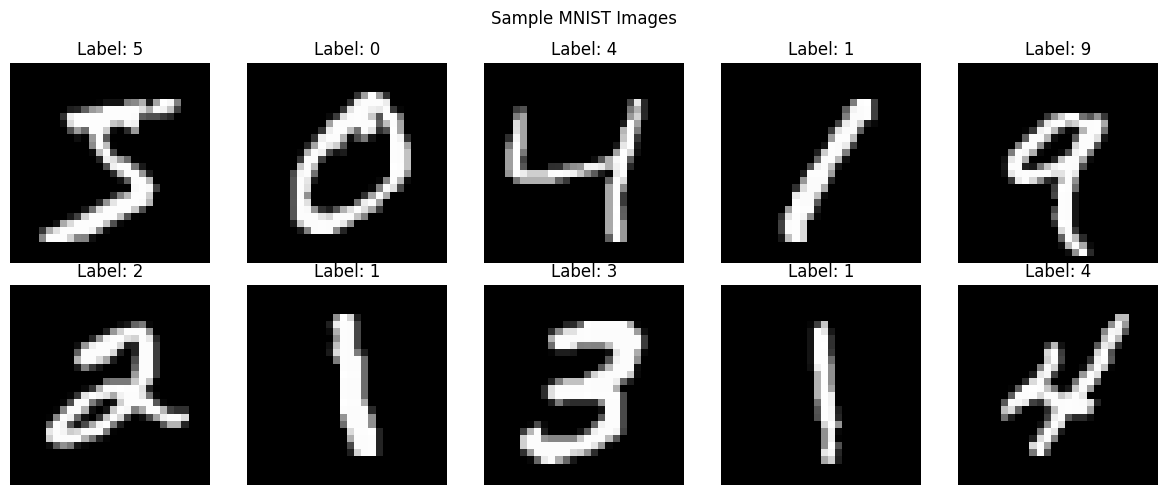

In [20]:
# Visualize some sample images
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i], cmap='gray')
    ax.set_title(f'Label: {y_train[i]}')
    ax.axis('off')
plt.suptitle('Sample MNIST Images')
plt.tight_layout()
plt.show()

### 3.2 Training with Gradient Descent

**Model Architecture:**
- Input: Flattened 28×28 image (784 features)
- Dense layer: 64 neurons + ReLU
- Output layer: 10 neurons + Softmax

In [21]:
def create_model():
    """Create a simple neural network for MNIST classification"""
    model = keras.Sequential([
        keras.layers.Input(shape=(784,)),
        keras.layers.Dense(64, activation='relu'),
        keras.layers.Dense(10, activation='softmax')
    ])
    return model

# Create and display model summary
model_sgd = create_model()
model_sgd.summary()

2026-02-05 17:10:34.112977: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,890 (198.79 KB)

 Trainable params: 50,890 (198.79 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
# Compile the model with SGD optimizer
sgd_optimizer = keras.optimizers.SGD(learning_rate=0.01)

model_sgd.compile(
    optimizer=sgd_optimizer,
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

print("Model compiled with SGD optimizer (learning_rate=0.01)")

Model compiled with SGD optimizer (learning_rate=0.01)


In [23]:
# Train the model
epochs = 20
batch_size = 32

history_sgd = model_sgd.fit(
    X_train_flat, y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=(X_test_flat, y_test),
    verbose=1
)

Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8221 - loss: 0.6977 - val_accuracy: 0.9008 - val_loss: 0.3742
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9029 - loss: 0.3503 - val_accuracy: 0.9147 - val_loss: 0.3033
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9147 - loss: 0.3004 - val_accuracy: 0.9203 - val_loss: 0.2769
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9235 - loss: 0.2713 - val_accuracy: 0.9287 - val_loss: 0.2514
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9297 - loss: 0.2499 - val_accuracy: 0.9341 - val_loss: 0.2324
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9345 - loss: 0.2325 - val_accuracy: 0.9393 - val_loss: 0.2165
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9394 - loss: 0.2175 - val_accuracy: 0.9410 - val_loss: 0.2063
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9420 - loss: 0.2050 - 

In [24]:
# Evaluate the model
test_loss, test_accuracy = model_sgd.evaluate(X_test_flat, y_test, verbose=0)
print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")


Test Loss: 0.1311
Test Accuracy: 0.9605


### 3.3 Observing Backpropagation

Use TensorFlow's automatic differentiation to inspect gradients of the loss with respect to weights.

In [25]:
# Create a fresh model for gradient inspection
model_grad = create_model()
loss_fn = keras.losses.SparseCategoricalCrossentropy()

# Get a small batch of data
batch_x = X_train_flat[:32]
batch_y = y_train[:32]

# Convert to tensors
batch_x = tf.constant(batch_x)
batch_y = tf.constant(batch_y)

In [26]:
# Use GradientTape to compute gradients
with tf.GradientTape() as tape:
    # Forward pass
    predictions = model_grad(batch_x, training=True)
    # Compute loss
    loss = loss_fn(batch_y, predictions)

# Compute gradients of loss w.r.t. trainable weights
gradients = tape.gradient(loss, model_grad.trainable_variables)

print(f"Loss: {loss.numpy():.4f}")
print(f"\nNumber of trainable variables: {len(model_grad.trainable_variables)}")

Loss: 2.2797

Number of trainable variables: 4


In [27]:
# Inspect gradients for each layer
for var, grad in zip(model_grad.trainable_variables, gradients):
    print(f"\nVariable: {var.name}")
    print(f"  Shape: {var.shape}")
    print(f"  Gradient shape: {grad.shape}")
    print(f"  Gradient mean: {tf.reduce_mean(grad).numpy():.6f}")
    print(f"  Gradient std: {tf.math.reduce_std(grad).numpy():.6f}")
    print(f"  Gradient min: {tf.reduce_min(grad).numpy():.6f}")
    print(f"  Gradient max: {tf.reduce_max(grad).numpy():.6f}")


Variable: kernel
  Shape: (784, 64)
  Gradient shape: (784, 64)
  Gradient mean: 0.000053
  Gradient std: 0.007342
  Gradient min: -0.059454
  Gradient max: 0.065210

Variable: bias
  Shape: (64,)
  Gradient shape: (64,)
  Gradient mean: 0.000939
  Gradient std: 0.021070
  Gradient min: -0.048251
  Gradient max: 0.062374

Variable: kernel
  Shape: (64, 10)
  Gradient shape: (64, 10)
  Gradient mean: -0.000000
  Gradient std: 0.016949
  Gradient min: -0.086079
  Gradient max: 0.060915

Variable: bias
  Shape: (10,)
  Gradient shape: (10,)
  Gradient mean: -0.000000
  Gradient std: 0.043841
  Gradient min: -0.096899
  Gradient max: 0.041303


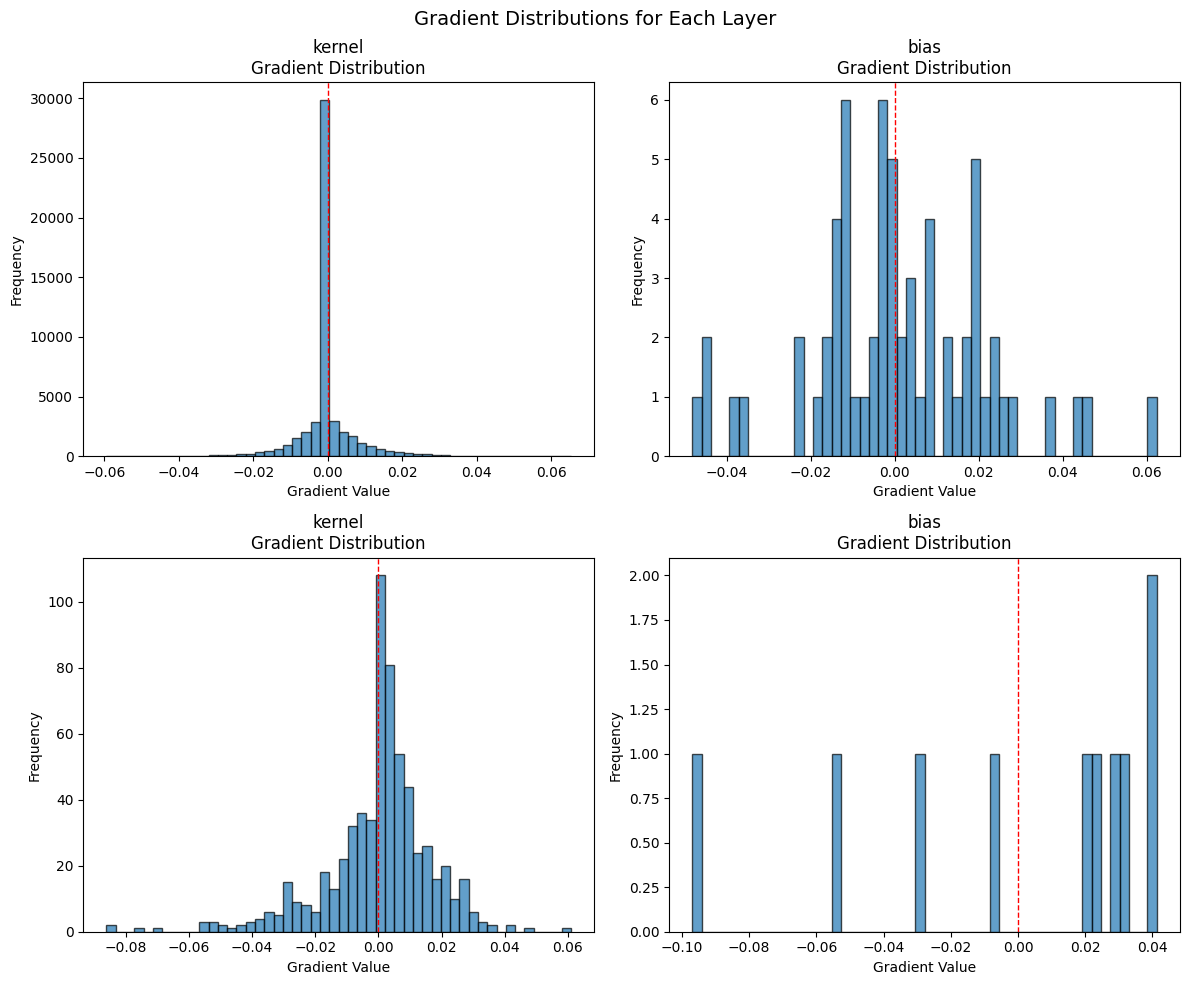

In [28]:
# Visualize gradient distributions
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for i, (var, grad) in enumerate(zip(model_grad.trainable_variables, gradients)):
    ax = axes.flat[i]
    grad_values = grad.numpy().flatten()
    ax.hist(grad_values, bins=50, edgecolor='black', alpha=0.7)
    ax.set_title(f'{var.name}\nGradient Distribution')
    ax.set_xlabel('Gradient Value')
    ax.set_ylabel('Frequency')
    ax.axvline(x=0, color='r', linestyle='--', linewidth=1)

plt.suptitle('Gradient Distributions for Each Layer', fontsize=14)
plt.tight_layout()
plt.show()

In [29]:
# Manual weight update demonstration
learning_rate_manual = 0.01

print("Demonstrating manual weight update:")
print("="*50)

# Get the first layer weights before update
weights_before = model_grad.trainable_variables[0].numpy().copy()
print(f"First layer weights (sample before update): {weights_before[0, :5]}")

# Manual update: new_weight = old_weight - learning_rate * gradient
for var, grad in zip(model_grad.trainable_variables, gradients):
    var.assign_sub(learning_rate_manual * grad)

# Get the first layer weights after update
weights_after = model_grad.trainable_variables[0].numpy()
print(f"First layer weights (sample after update):  {weights_after[0, :5]}")
print(f"\nWeight change: {(weights_after - weights_before)[0, :5]}")

Demonstrating manual weight update:
First layer weights (sample before update): [ 0.03842224  0.05254558 -0.00553985 -0.01674467  0.04475249]
First layer weights (sample after update):  [ 0.03842224  0.05254558 -0.00553985 -0.01674467  0.04475249]

Weight change: [0. 0. 0. 0. 0.]


## Part 4 – Comparing Optimizers

### 4.1 SGD vs Adam

Train two identical models with different optimizers and compare their performance.

In [30]:
# Set random seeds for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

# Training parameters (same for both models)
epochs = 20
batch_size = 32

In [31]:
# Model 1: SGD optimizer
tf.random.set_seed(42)
model_sgd_compare = create_model()
model_sgd_compare.compile(
    optimizer=keras.optimizers.SGD(learning_rate=0.01),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

print("Training model with SGD optimizer...")
history_sgd_compare = model_sgd_compare.fit(
    X_train_flat, y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=(X_test_flat, y_test),
    verbose=1
)

Training model with SGD optimizer...
Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8240 - loss: 0.6871 - val_accuracy: 0.9003 - val_loss: 0.3636
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9051 - loss: 0.3407 - val_accuracy: 0.9181 - val_loss: 0.2962
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9171 - loss: 0.2927 - val_accuracy: 0.9252 - val_loss: 0.2655
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9249 - loss: 0.2645 - val_accuracy: 0.9323 - val_loss: 0.2448
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9309 - loss: 0.2435 - val_accuracy: 0.9361 - val_loss: 0.2285
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9355 - loss: 0.2264 - val_accuracy: 0.9392 - val_loss: 0.2149
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9403 - loss: 0.2119 - val_accuracy: 0.9429 - val_loss: 0.2031
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step

In [32]:
# Model 2: Adam optimizer
tf.random.set_seed(42)
model_adam = create_model()
model_adam.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

print("Training model with Adam optimizer...")
history_adam = model_adam.fit(
    X_train_flat, y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=(X_test_flat, y_test),
    verbose=1
)

Training model with Adam optimizer...
Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9165 - loss: 0.2941 - val_accuracy: 0.9496 - val_loss: 0.1690
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9585 - loss: 0.1427 - val_accuracy: 0.9622 - val_loss: 0.1248
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9690 - loss: 0.1051 - val_accuracy: 0.9668 - val_loss: 0.1100
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9754 - loss: 0.0835 - val_accuracy: 0.9684 - val_loss: 0.1037
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9804 - loss: 0.0686 - val_accuracy: 0.9698 - val_loss: 0.1000
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9834 - loss: 0.0574 - val_accuracy: 0.9712 - val_loss: 0.0959
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9861 - loss: 0.0484 - val_accuracy: 0.9716 - val_loss: 0.0966
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/ste

In [33]:
# Evaluate both models
print("\n" + "="*50)
print("Final Results Comparison")
print("="*50)

sgd_loss, sgd_acc = model_sgd_compare.evaluate(X_test_flat, y_test, verbose=0)
adam_loss, adam_acc = model_adam.evaluate(X_test_flat, y_test, verbose=0)

print(f"\nSGD Optimizer:")
print(f"  Test Loss: {sgd_loss:.4f}")
print(f"  Test Accuracy: {sgd_acc:.4f}")

print(f"\nAdam Optimizer:")
print(f"  Test Loss: {adam_loss:.4f}")
print(f"  Test Accuracy: {adam_acc:.4f}")


Final Results Comparison

SGD Optimizer:
  Test Loss: 0.1267
  Test Accuracy: 0.9631

Adam Optimizer:
  Test Loss: 0.1330
  Test Accuracy: 0.9723


### 4.2 Visualization

Plot training loss and accuracy for both optimizers.

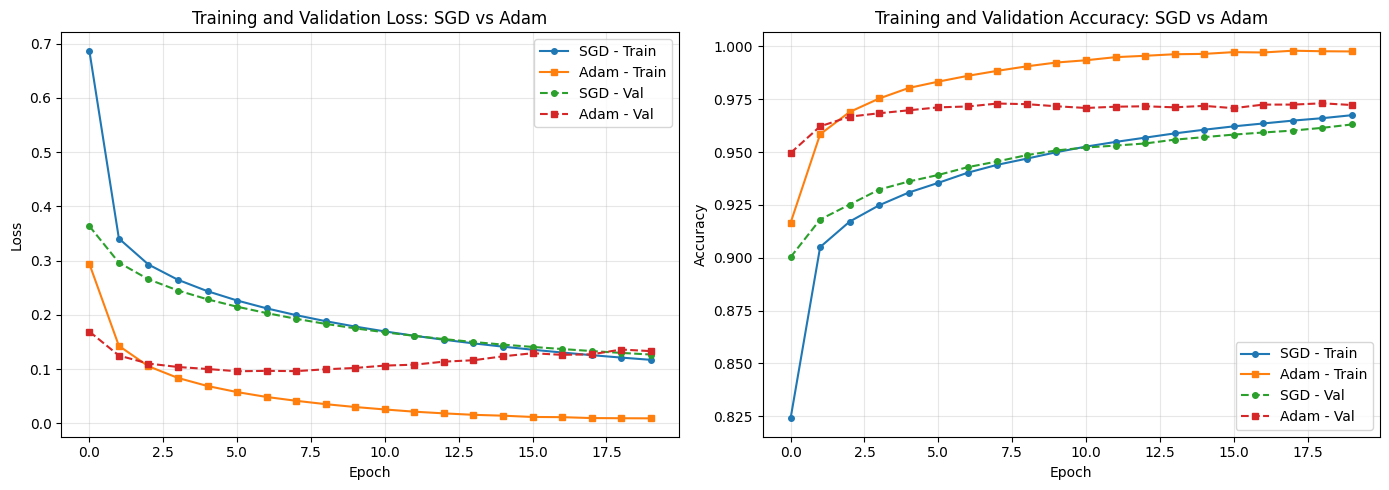

In [34]:
# Plot training loss comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training Loss
axes[0].plot(history_sgd_compare.history['loss'], label='SGD - Train', linestyle='-', marker='o', markersize=4)
axes[0].plot(history_adam.history['loss'], label='Adam - Train', linestyle='-', marker='s', markersize=4)
axes[0].plot(history_sgd_compare.history['val_loss'], label='SGD - Val', linestyle='--', marker='o', markersize=4)
axes[0].plot(history_adam.history['val_loss'], label='Adam - Val', linestyle='--', marker='s', markersize=4)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss: SGD vs Adam')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Training Accuracy
axes[1].plot(history_sgd_compare.history['accuracy'], label='SGD - Train', linestyle='-', marker='o', markersize=4)
axes[1].plot(history_adam.history['accuracy'], label='Adam - Train', linestyle='-', marker='s', markersize=4)
axes[1].plot(history_sgd_compare.history['val_accuracy'], label='SGD - Val', linestyle='--', marker='o', markersize=4)
axes[1].plot(history_adam.history['val_accuracy'], label='Adam - Val', linestyle='--', marker='s', markersize=4)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training and Validation Accuracy: SGD vs Adam')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

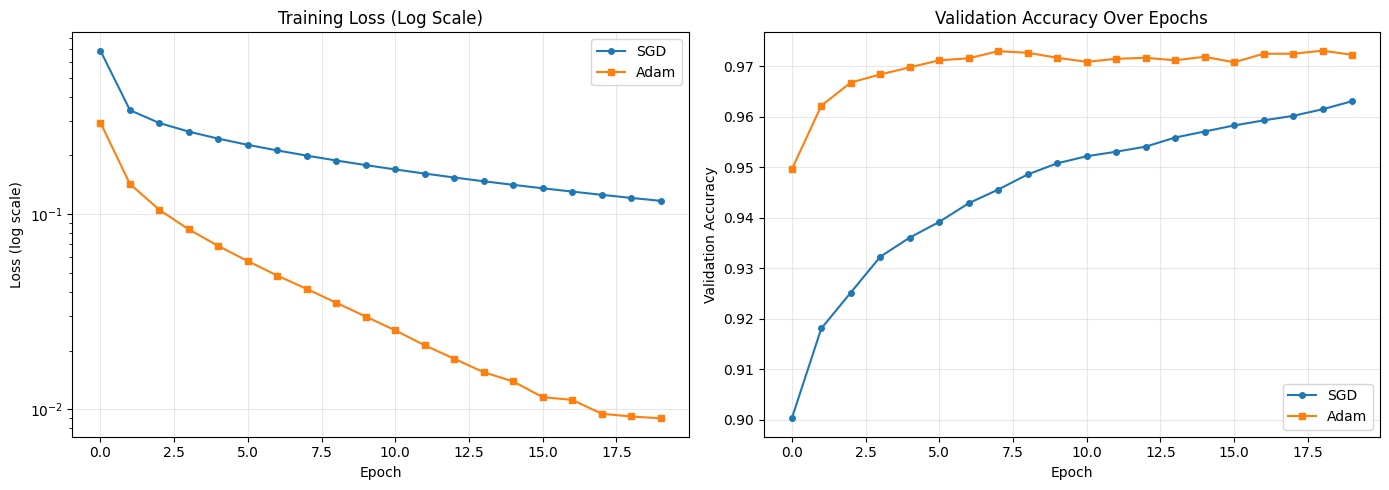

In [35]:
# Additional visualization: convergence speed comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss difference from final value (to show convergence speed)
sgd_loss_final = history_sgd_compare.history['loss'][-1]
adam_loss_final = history_adam.history['loss'][-1]

axes[0].semilogy(history_sgd_compare.history['loss'], label='SGD', marker='o', markersize=4)
axes[0].semilogy(history_adam.history['loss'], label='Adam', marker='s', markersize=4)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (log scale)')
axes[0].set_title('Training Loss (Log Scale)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy improvement
axes[1].plot(history_sgd_compare.history['val_accuracy'], label='SGD', marker='o', markersize=4)
axes[1].plot(history_adam.history['val_accuracy'], label='Adam', marker='s', markersize=4)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Validation Accuracy')
axes[1].set_title('Validation Accuracy Over Epochs')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Key Observations:**
- Adam typically converges faster in the early epochs
- SGD may require more epochs but can sometimes achieve better generalization
- Adam adapts learning rates per parameter, which helps with sparse gradients

## Part 5 – Theoretical Questions

### Q1. What is the role of the learning rate in gradient descent?

**Answer:**

The learning rate ($\alpha$) controls the step size of parameter updates during optimization:

$$\theta_{new} = \theta_{old} - \alpha \cdot \nabla L$$

Its role includes:

1. **Controls convergence speed**: A larger learning rate leads to faster initial progress, while a smaller one results in slower but more stable updates.

2. **Affects stability**: 
   - Too large: Can cause the optimization to overshoot the minimum, leading to oscillations or divergence
   - Too small: Results in very slow convergence and may get stuck in local minima

3. **Trade-off**: The learning rate represents a balance between speed and precision. It determines whether we take big, fast steps (potentially missing the optimum) or small, careful steps (slow but precise).

### Q2. Why do we need backpropagation in multi-layer neural networks?

**Answer:**

Backpropagation is essential for training multi-layer neural networks because:

1. **Computing gradients efficiently**: In a multi-layer network, we need to compute how the loss changes with respect to weights in ALL layers, not just the output layer. Backpropagation uses the chain rule to efficiently compute these gradients by propagating error signals backward through the network.

2. **Handling composition of functions**: A neural network is a composition of many functions (layers). To update weights in early layers, we need to know how changes in those weights affect the final output through all intermediate layers:
   $$\frac{\partial L}{\partial W_1} = \frac{\partial L}{\partial y} \cdot \frac{\partial y}{\partial h_n} \cdot ... \cdot \frac{\partial h_2}{\partial h_1} \cdot \frac{\partial h_1}{\partial W_1}$$

3. **Computational efficiency**: Without backpropagation, computing gradients would require separate forward passes for each weight, which is computationally infeasible. Backpropagation computes all gradients in one forward and one backward pass.

### Q3. What happens if gradients become very small during training?

**Answer:**

When gradients become very small, we encounter the **vanishing gradient problem**:

1. **Slow or stalled learning**: Parameter updates become negligibly small ($\Delta w \approx 0$), causing the network to stop learning effectively.

2. **Affects early layers most**: In deep networks, gradients are multiplied through many layers during backpropagation. If these gradients are < 1, they exponentially decay, affecting earlier layers the most.

3. **Common causes**:
   - Saturating activation functions (sigmoid, tanh) where derivatives approach 0
   - Poor weight initialization
   - Very deep networks

4. **Solutions**:
   - Use ReLU or Leaky ReLU activations
   - Proper weight initialization (Xavier, He)
   - Batch normalization
   - Skip connections (ResNet)
   - Gradient clipping

### Q4. Why does Adam often converge faster than plain SGD?

**Answer:**

Adam (Adaptive Moment Estimation) converges faster than plain SGD because it incorporates several improvements:

1. **Adaptive learning rates**: Adam maintains individual learning rates for each parameter, automatically adjusting them based on the history of gradients. Parameters with large gradients get smaller effective learning rates, and vice versa.

2. **Momentum (First moment)**: Adam uses exponentially weighted moving average of gradients ($m_t$), which helps:
   - Accelerate through flat regions
   - Dampen oscillations in steep directions
   - Navigate saddle points more effectively

3. **RMSprop-like scaling (Second moment)**: Adam also tracks the exponentially weighted average of squared gradients ($v_t$), normalizing updates by the magnitude of recent gradients.

4. **Bias correction**: Adam corrects for the initialization bias in the moment estimates, ensuring stable updates from the beginning of training.

The update rule combines these:
$$\theta_t = \theta_{t-1} - \alpha \cdot \frac{\hat{m}_t}{\sqrt{\hat{v}_t} + \epsilon}$$

This makes Adam particularly effective for sparse gradients, noisy problems, and non-stationary objectives.